# Homework 1

Basically, solve any physical system of differential equations by applying Euler's method.

In [2]:
import numpy as np
import matplotlib.pyplot as plt

## Method implementation

Basically, here we'll implement Euler's method. 

In short words, what we want here is that, given a differential equation of whatever shape we want, separate each one of it's terms independently, and treat each one of those equations as some sort of "first order differential equation" and thus, updating each step as if it were a simple order differential equation following

$$
    y_{n+1} = y_{n} + h \dot y_n
$$

with a given step size $h$.

## Classical Harmonic Oscillator

In this section, we'll check the behavior of the general classical harmonic oscilator, which is given by the second order differential equation

$$
    m\frac{d^2}{d t^2} x + c \frac{d}{dt} x + k x = 0
$$

where $c$ and $k$ are the damping and elastic strength constants. We can also write the same equation in a more interesting form

$$
    \ddot x + 2 \beta \dot x + \omega_0^2 x = 0,
$$

where each $\beta$ and $\omega$ are related to the prior and as physicist we already shall know what they are.

In this case, from this equation, we can get the update step for the velocity $\dot x$ given by


$$
    \dot x_{n+1} = \dot x_n + h \ddot x_n
$$

where

$$
    \begin{gather}
        \ddot x_n = - 2\beta \dot x_n - \omega_0^2 x_n. \\
    \end{gather}
$$

Finally, we can get the update step for the postion as a simple Leapfrog update

$$
    x_{n+1} = x_n + h \dot x_n
$$


_NOTE: all we did here bout the harmonic oscillator is supposing that the natural length is $x_0 = 0$, of course, we're physicist_

In [43]:
def update_position(xn, dxn, h = 0.01):
    ''' Rule to update the position, a simple leapfrog '''
    return xn + h * dxn

def update_velocity(dxn, ddxn, h = 0.01):
    ''' Simple rule to update the velocity, leapfrog once again.
    The acceleration rule is calculated outside just to make the code prettier '''
    return dxn + h * ddxn

def calculate_acceleration(dxn, xn, beta, omega):
    ''' Calculate the current acceleration using the drag constant and frequency. '''
    return - 2.0 * beta * dxn - omega**2 * xn



def update_system(xn, dxn, beta, omega, h = 0.01):
    ''' Here we'll do the whole updating process for the position and velocity '''

    current_acceleration = calculate_acceleration(dxn, xn, beta, omega)
    new_x = update_position(xn, dxn, h)
    new_dx = update_velocity(dxn, current_acceleration)

    return (new_x, new_dx, current_acceleration)



def simulate_system(xn0, dxn0, beta, omega, h, n):
    ''' Here, we'll make a loop to simulate the whole system we want and plot all the values '''

    data = [(xn0, dxn0, calculate_acceleration(dxn0, xn0, beta, omega))]
    
    for i in range(int(n)):
        data.append(update_system(data[-1][0], data[-1][1], beta, omega, h))

    # PLOTTING
    
    # Unpack the tuples we created priorly (poor choice of design but whatever)
    position = [p for p, v, a in data]
    velocity = [v for p, v, a in data]
    acceleration = [a for p, v, a in data]
    
    # If each tuple corresponds to one time step:
    t = range(len(data))
    
    plt.plot(t, position, label='Position')
    plt.plot(t, velocity, label='Velocity')
    plt.plot(t, acceleration, label='Acceleration')
    
    plt.xlabel('Time step')
    plt.ylabel('Value')
    plt.legend()
    plt.grid(True)
    plt.show()
    
    return data
        




With the prior, we can model all different systems of harmonic oscillators. Such as the simple one without any sort of damping force

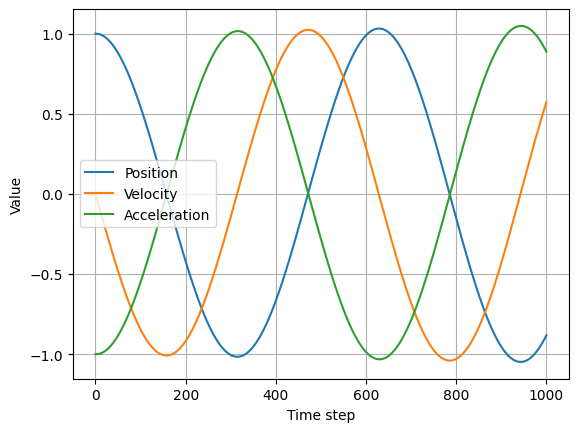

In [44]:
system = simulate_system(1.0, 0.0, 0.0, 1.0, 0.01, 1e3)

Or adding more damping

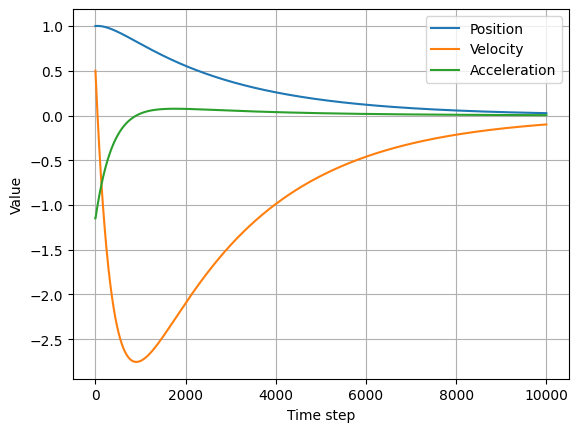

In [45]:
system = simulate_system(1.0, 0.5, 0.15, 1.0, 0.0001, 1e4)

Or a little less damping just to see in a better way the effects

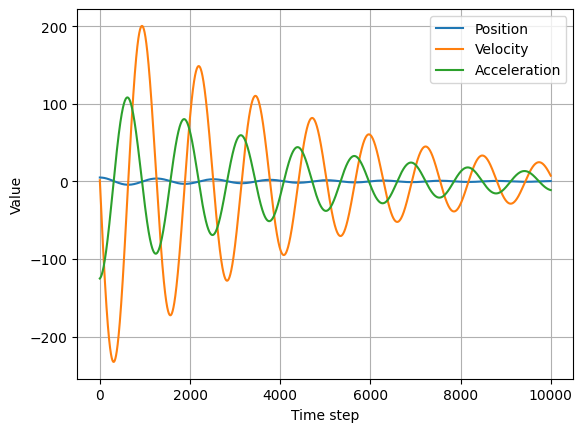

In [46]:
system = simulate_system(5.0, 1.5, 0.025, 5.0, 0.0001, 1e4)